In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [83]:
BENCHMARK_FILE_NAMES = {
    "CPU_Disk_0": "CPU_Scaling_Disk_0.txt", 
    "CPU_Disk_1": "CPU_Scaling_Disk_1.txt",
    "CPU_Triangle_0": "CPU_Scaling_Triangle_0.txt",
    "CPU_Triangle_1": "CPU_Scaling_Triangle_1.txt"
}
STEPS = ["Meshing", "Tracing", "Postprocessing", "RayTraced"]


In [84]:
def load_benchmark_data(benchmark_path=None):
    """Load all benchmark files into a dictionary of DataFrames.

    Args:a
        benchmark_path: Optional path to directory containing benchmark files.
                       If None, uses current directory.
    """
    data = {}
    if benchmark_path is None:
        benchmark_path = Path(".")
    else:
        benchmark_path = Path(benchmark_path)

    for name, filename in BENCHMARK_FILE_NAMES.items():
        filepath = benchmark_path / filename
        try:
            df = pd.read_csv(filepath, sep=";")
            data[name] = df
            print(f"Loaded {name}: {len(df)} runs from {filepath}")
        except FileNotFoundError:
            print(f"Warning: {filepath} not found")
    return data

def calculate_statistics(data, key):
    """Calculate mean and std for each configuration and step."""
    stats = {}

    for config_name, df in data.items():
        config_stats = {}

        # Group by key
        for grid_delta in df[key].unique():
            subset = df[df[key] == grid_delta]
            grid_stats = {}

            for step in STEPS:
                if step in subset.columns:
                    grid_stats[step] = {
                        "mean": subset[step].mean(),
                        "std": subset[step].std(),
                        "min": subset[step].min(),
                        "max": subset[step].max(),
                    }

            config_stats[grid_delta] = grid_stats

        stats[config_name] = config_stats

    return stats

In [85]:
data = load_benchmark_data(benchmark_path="/home/reiter/Code/ViennaPS/build/gpu/benchmark")

Loaded CPU_Disk_0: 50 runs from /home/reiter/Code/ViennaPS/build/gpu/benchmark/CPU_Scaling_Disk_0.txt
Loaded CPU_Disk_1: 50 runs from /home/reiter/Code/ViennaPS/build/gpu/benchmark/CPU_Scaling_Disk_1.txt
Loaded CPU_Triangle_0: 50 runs from /home/reiter/Code/ViennaPS/build/gpu/benchmark/CPU_Scaling_Triangle_0.txt
Loaded CPU_Triangle_1: 50 runs from /home/reiter/Code/ViennaPS/build/gpu/benchmark/CPU_Scaling_Triangle_1.txt


In [86]:
stats = calculate_statistics(data, key="NumThreads")
num_threads = sorted(data[list(data.keys())[0]]["NumThreads"].unique())
configs = list(stats.keys())

In [87]:
stats

{'CPU_Disk_0': {1: {'Meshing': {'mean': 30707050.2,
    'std': 3295951.087057769,
    'min': 29107610,
    'max': 39969714},
   'Tracing': {'mean': 98742028144.6,
    'std': 1341604073.5487084,
    'min': 97093217239,
    'max': 100964055227},
   'Postprocessing': {'mean': 1428740.3,
    'std': 77485.5648148594,
    'min': 1378418,
    'max': 1641753},
   'RayTraced': {'mean': 312116483.3,
    'std': 72083.20343117388,
    'min': 311963705,
    'max': 312189033}},
  2: {'Meshing': {'mean': 28204367.1,
    'std': 1873199.5831873366,
    'min': 26881184,
    'max': 33096082},
   'Tracing': {'mean': 51172390730.9,
    'std': 481163945.9640113,
    'min': 50419169723,
    'max': 52063682297},
   'Postprocessing': {'mean': 1681778.9,
    'std': 166369.00771708254,
    'min': 1364068,
    'max': 1945008},
   'RayTraced': {'mean': 312175104.8,
    'std': 51777.11991003148,
    'min': 312096498,
    'max': 312263550}},
  4: {'Meshing': {'mean': 25927135.1,
    'std': 1327712.5179604916,
    'm

In [95]:
def extract_runtimes(keys, metric="mean"):
    runtimes = {}
    for config in configs:
        runtimes[config] = []
        for num_thread in num_threads:
            runtime = 0
            for key in keys:
                runtime += stats[config][num_thread][key][metric]
            runtimes[config].append(runtime / 1e9)
    return runtimes


In [96]:
color_map = {
    "CPU_Disk_0": "#6baed6",  # Light blue
    "CPU_Disk_1": "#08519c",  # Dark blue
    "CPU_Triangle_0": "#fdae6b",  # Light orange
    "CPU_Triangle_1": "#d94801",  # Dark orange
}

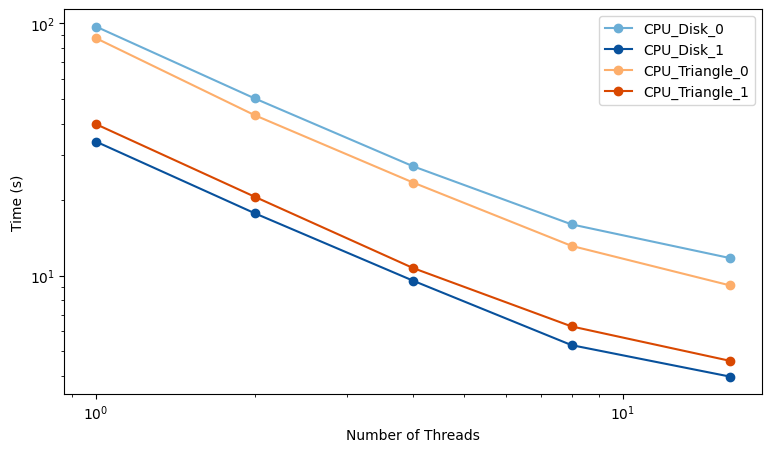

In [98]:
fig, ax = plt.subplots(figsize=(9, 5))

runtimes = extract_runtimes(["Tracing", "Postprocessing", "Meshing"], metric="min")
for config in configs:
    ax.plot(num_threads, runtimes[config], label=config, marker="o", color=color_map.get(config, "#000000"))

ax.set_xlabel("Number of Threads")
ax.set_ylabel("Time (s)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()

plt.show()